## Importing

In [9]:
import tensorflow as tf
from tensorflow.keras import layers,Model
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

## Defining Constants

In [10]:
HEIGHT=638
WIDTH=1013
CHANNELS= 3
IMAGE_SHAPE= (638, 1013, 3)
msize=24 

# Texture Feature Branch

### Architecture

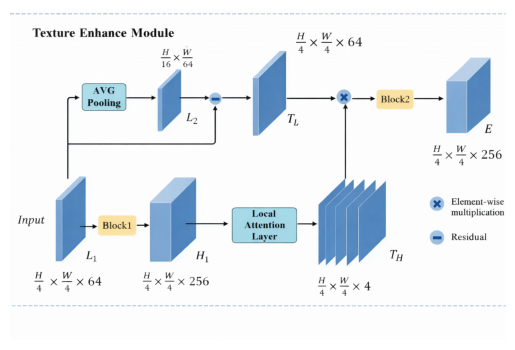

In [5]:
archi= mpimg.imread('texture_feature.png')
plt.imshow(archi)
plt.axis('off')
plt.show()

### L1 (Extracts general features)


In [6]:
def l1(inputs):
    x=layers.Conv2D(64,3,
                    strides=1,
                    padding='same',
                    use_bias=False, # yespaxi hami normalization garxam aarko layer ma so rakhna parder
                    name='l1_conv'
                   )(inputs)
    x= layers.BatchNormalization(name='l1_batch')(x)
    x= layers.ReLU(name='l1_relu')(x)

    return x
    

### Block 1
Learn more from texure or edges made by L1(h/4,w/4,64) and output is H1 (h/4,w/4,256)

In [16]:
def block1(img):

    l1_img=img
    
    x=layers.Conv2D(64,3,
                    strides=1,
                    padding='same',
                    use_bias=False,
                    name='b1_conv1'
                   )(img)
    x= layers.BatchNormalization(name='b1_batch1')(x)
    x= layers.ReLU(name='b1_relu1')(x)

    x=layers.Conv2D(64,3,
                    strides=1,
                    padding='same',
                    use_bias=False,
                    name='b1_conv2'
                   )(x)
    x= layers.BatchNormalization(name='b1_batch2')(x)
    """
    if we don't add new x with prev, residual model had to choose between them and 
    with it model learns only what to add to on top of what already exists
    """
    
    x = layers.Add(name="b1_add")([x, l1_img])
    x= layers.ReLU(name='b1_relu2')(x)
    
    return x

     

### Local Attention Layer
A(X) = ELU(BN(Conv1x1(X))) + 1  
M1 = Interpolate(M, size=(H_H1, W_H1))  
T_H = A(X) * M1


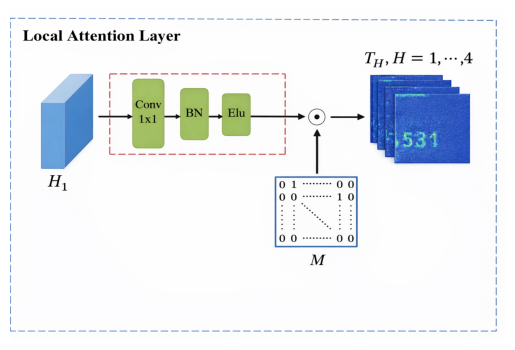

In [17]:
archi= mpimg.imread('local_attention.png')
plt.imshow(archi)
plt.axis('off')
plt.show()

In [21]:
## we are making this matrix to make attention layer focus on central areas leaving few border (2)
M=np.zeros((msize,msize),dtype=np.float32)
M[2:-2,2:-2]=1.0

In [22]:
def local_attention (img):
    x = layers.Conv2D(4, 1, padding="same", use_bias=False, name="local_attn_conv")(img)
    x = layers.BatchNormalization(name="local_attn_bn")(x)

    #why elu -> elu keeps negative values too but ReLU initializes them to 0 ani feature gayeb
    x = layers.ELU(name="local_attn_elu")(x)
    x = layers.Lambda(lambda z: z + 1, name="local_attn_add1")(x)

    #interpolating the size of M to match with size of x
    M_tensor = tf.constant(M[np.newaxis, :, :, np.newaxis], dtype=tf.float32)

    target_h = tf.shape(x)[1] # height of H1
    target_w = tf.shape(x)[2] #width

    M1 = tf.image.resize(M_tensor, [target_h, target_w], method='bilinear')
 
    #Multiplying
    T_H= layers.Lambda(lambda z: z* M1, name='local_attn_multiply')(x)
    return T_H

### Difference feature
input -> (H/4,W/4,64)

In [7]:
def difference_feature(l1):
    l2= layers.AveragePooling2D(pool_size=4,
                               strides=4,
                               padding='same',
                               name="l2_avgpool")(l1)
    #(h/16,w/16,64)
    l2_up=layers.UpSampling2D(
        size=4,
        interpolation='bilinear',
        name='l2_upsample'
    )(l2)
    T_L=layers.Subtract(name='T_L')([l1,l2_up])

    return T_L

    

### Multiplication Before Block 2
-> T_H channels need to be upscaled to 64  
-> Then multiply

### Block 2
inp - (h/4,w/4,64)  
out - (h/4,w/4,256)

In [5]:
def block2(x):
    # Layer 1
    d1 = layers.Conv2D(64, 3, padding='same', use_bias=False, name='b2_conv1')(x)
    d1 = layers.BatchNormalization(name='b2_batch1')(d1)
    d1 = layers.ReLU(name='b2_relu1')(d1)

    # Layer 2 — receives x and d1
    d2_input = layers.Concatenate(name='b2_concat1')([x, d1])
    d2 = layers.Conv2D(64, 3, padding='same', use_bias=False, name='b2_conv2')(d2_input)
    d2 = layers.BatchNormalization(name='b2_batch2')(d2)
    d2 = layers.ReLU(name='b2_relu2')(d2)

    # Layer 3 — receives x, d1 and d2
    d3_input = layers.Concatenate(name='b2_concat2')([x, d1, d2])
    d3 = layers.Conv2D(64, 3, padding='same', use_bias=False, name='b2_conv3')(d3_input)
    d3 = layers.BatchNormalization(name='b2_batch3')(d3)
    d3 = layers.ReLU(name='b2_relu3')(d3)

    # Final projection to 256 channels
    E = layers.Concatenate(name='b2_concat_final')([x, d1, d2, d3])
    E = layers.Conv2D(256, 1, padding='same', use_bias=False, name='b2_conv_final')(E)
    E = layers.BatchNormalization(name='b2_batchf')(E)
    E = layers.ReLU(name='b2_reluf')(E)

    return E